In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv("../dataset/updated_pollution_dataset.csv")

df["Air Quality"] = df["Air Quality"].map({
    "Good": 0,
    "Moderate": 0,
    "Poor": 1,
    "Hazardous": 1
})

In [7]:
print(df["Air Quality"].value_counts())
print(df["Air Quality"].unique())

Air Quality
0    3500
1    1500
Name: count, dtype: int64
[0 1]


In [8]:
X = df.drop("Air Quality", axis=1)
y = df["Air Quality"]

In [16]:
import numpy as np

def entropy(feature):

    # Calculate probabilities
    p = feature.value_counts() / feature.shape[0]

    # Entropy formula
    entropy = -np.sum(p * np.log2(p + 1e-9))

    return entropy
entropy(df["Air Quality"])

np.float64(0.8812908963453026)

In [17]:
def gini_impurity(feature):

    # Calculate probabilities
    p = feature.value_counts() / feature.shape[0]

    # Gini formula
    gini = 1 - np.sum(p ** 2)

    return gini
gini_impurity(df["Air Quality"])

np.float64(0.42000000000000004)

In [19]:
import numpy as np

def information_gain(feature, mask):

    # Entropy before split
    parent_entropy = entropy(feature)

    # Split the data
    left = feature[mask]
    right = feature[~mask]

    # If one side is empty
    if len(left) == 0 or len(right) == 0:
        return 0

    # Number of samples
    n = len(feature)

    # Weighted entropy after split
    child_entropy = (
        (len(left) / n) * entropy(left)
        + (len(right) / n) * entropy(right)
    )

    # Information Gain
    gain = parent_entropy - child_entropy

    return gain
gain = information_gain(
    df["Air Quality"],
    df["PM2.5"] <= df["PM2.5"].median()
)

print("Information Gain:", gain)

Information Gain: 0.04916943309254296


In [9]:
import numpy as np
from collections import Counter

In [ ]:
from collections import Counter

class Node:
    """
    Represents a decision tree node.
    A node can be either:
    - Decision node (has feature and threshold)
    - Leaf node (has final prediction value)
    """

    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeScratch:

    def __init__(self, min_samples_split=2, max_depth=5, n_features=None, random_state=42):
        
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.random_state = random_state
        self.root = None

    def fit(self, X, y):

        np.random.seed(self.random_state)
        # Use all features if n_features is not specified
        self.n_features = (
            X.shape[1] 
            if self.n_features is None 
            else min(self.n_features, X.shape[1])
        )
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        # Stopping conditions
        if (
            depth >= self.max_depth
            or n_labels == 1
            or n_samples < self.min_samples_split
        ):
            leaf_value = self._most_common_label(y)

            return Node(value=leaf_value)
        # Random feature selection (useful for Random Forest)
        feature_indices = np.random.choice(
            n_features,
            self.n_features,
            replace=False
        )
        # Find best split
        best_feature, best_threshold = self._best_split(
            X,
            y,
            feature_indices
        )
        # If no useful split found
        if best_feature is None:
            return Node(
                value=self._most_common_label(y)
            )
        # Split data
        left_indices, right_indices = self._split(
            X[:, best_feature],
            best_threshold
        )
        # Create child nodes
        left_child = self._build_tree(
            X[left_indices, :],
            y[left_indices],
            depth + 1
        )
        right_child = self._build_tree(
            X[right_indices, :],
            y[right_indices],
            depth + 1
        )
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_child,
            right=right_child
        )
    def _best_split(self, X, y, feature_indices):
        best_gain = -1
        best_feature = None
        best_threshold = None
        for feature in feature_indices:
            feature_values = X[:, feature]
            thresholds = np.unique(feature_values)
            for threshold in thresholds:
                gain = self._information_gain(
                    y,
                    feature_values,
                    threshold
                )
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold
    def _information_gain(self, y, feature_column, threshold):
        # Entropy before split
        parent_entropy = self._entropy(y)
        left_indices, right_indices = self._split(
            feature_column,
            threshold
        )
        # Invalid split
        if len(left_indices) == 0 or len(right_indices) == 0:
            return 0
        n = len(y)
        left_entropy = self._entropy(
            y[left_indices]
        )
        right_entropy = self._entropy(
            y[right_indices]
        )
        weighted_entropy = (
            (len(left_indices) / n) * left_entropy
            +
            (len(right_indices) / n) * right_entropy
        )
        # Information gain
        gain = parent_entropy - weighted_entropy
        return gain
    def _split(self, feature_column, threshold):
        left_indices = np.argwhere(
            feature_column <= threshold
        ).flatten()
        right_indices = np.argwhere(
            feature_column > threshold
        ).flatten()
        return left_indices, right_indices
    def _entropy(self, y):
        counts = np.bincount(y)
        probabilities = counts / len(y)
        entropy = -np.sum(
            [
                p * np.log2(p)
                for p in probabilities
                if p > 0
            ]
        )
        return entropy
    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    def predict(self, X):
        predictions = [
            self._traverse_tree(sample, self.root)
            for sample in X
        ]
        return np.array(predictions)
    def _traverse_tree(self, sample, node):
        if node.is_leaf_node():
            return node.value
        if sample[node.feature] <= node.threshold:
            return self._traverse_tree(
                sample,
                node.left
            )
        return self._traverse_tree(
            sample,
            node.right
        )

In [24]:
X.shape, y.shape

((5000, 9), (5000,))

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [26]:
X_train, X_test

y_train,y_test

(4227    1
 4676    0
 800     1
 3671    0
 4193    0
        ..
 4426    0
 466     0
 3092    1
 3772    0
 860     1
 Name: Air Quality, Length: 4000, dtype: int64,
 1501    1
 2586    0
 2653    0
 1055    1
 705     0
        ..
 4711    0
 2313    0
 3214    1
 2732    0
 1926    1
 Name: Air Quality, Length: 1000, dtype: int64)

In [27]:
model = DecisionTreeScratch(max_depth=5)
model.fit(X_train, np.array(y_train))

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.978
Precision: 0.9725085910652921
Recall   : 0.9528619528619529
F1 Score : 0.9625850340136054

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       703
           1       0.97      0.95      0.96       297

    accuracy                           0.98      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000



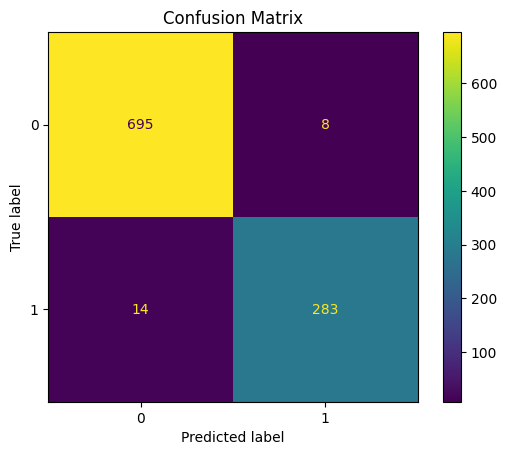

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()